# ADEPT Sensitivity Analysis: Federated Learning System

This notebook exercises the ADEPT framework's real analysis methodology end to
end against the Federated Learning example: model summary (R4), an explicit
spec-linting sanity check (R1-R3), tradeoff definition, per-decision
contingency analysis for FL's 3 composed pattern decisions, key-parameter
selection via smart correlation with FL's policy-bound pattern parameters
included (R6), PRIM/CART scenario discovery (R9), and box-diagnostics
visualization including a best-effort search for an optional parameter's
"not selected" N/A-hatching state (R10).

It retires `federatedlearning/test_manual_simple.py`,
`federatedlearning/test_nan_feature.ipynb`, and root `test_nan_manual.py` as
the primary validation path (R11); those files remain in place, unmodified.

> **Focused analysis: **Client Selector Only** (`ON,OFF,OFF`).**
>
> Generated from `analysis-fl.ipynb` by `make_slice_notebooks.py`; edit the base notebook and regenerate instead of editing this one.
> Only the runs of this slice are loaded (`fl_slices.py`). Tradeoffs use **fixed bin edges** (`TRADEOFF_EDGES` in the parameters cell): the edges the base notebook detects on the full dataset, so `S`/`M`/`L` and the regions are the same as in the other notebooks and densities are comparable across them (paper plan §4.4-4.5).
> With the current 32-run dataset a slice holds 5-10 runs, so expect few or no boxes: the notebook is ready to be re-run on the larger dataset.


In [1]:
# Set project root in path so we can import 'adept' package
import sys
sys.path.append("..")

import itertools
import json
import pandas as pd
import matplotlib.pyplot as plt

from adept import PatternAnalysis
from adept.utils.linter import SystemLinter
from adept.utils.spec_summary import summarize_system

import fl_slices

# No preprocessor is needed: FLsystem_split.json declares how the per-client columns
# ("Client <N> <field>") are aggregated into system-level parameters and objectives
# (dataspace.aggregations, see adept/utils/aggregation.py).

In [2]:
# ---- Analysis parameters
# Which runs to analyze (see fl_slices.py). Focused notebooks are generated from this one
# by make_slice_notebooks.py, which only changes this cell.
#   'all'                -> every run (this notebook)
#   'baseline'           -> All Patterns Off
#   'client_selector', 'message_compressor', 'hdh' -> that pattern alone ON
SLICE = 'client_selector'
# For a single-pattern slice, also keep the baseline runs (pattern ON vs. not applied)
INCLUDE_BASELINE = False
SPEC = './FLsystem_split.json'

# Tradeoffs (Section 3): the bins of each objective, and their edges.
#   TRADEOFF_EDGES = None -> edges detected from the loaded data (equal-width bins over its
#                            range, padded by 0.1)
#   {objective: [e0, ..., en]} -> fixed edges for the n labels of that objective. The
#                            focused notebooks get the edges detected on the full dataset
#                            (make_slice_notebooks.py), so they share this notebook's regions.
TRADEOFF_LABELS = {
    'final_val_accuracy': ['S', 'M', 'L'],
    'avg_total_time': ['S', 'M', 'L'],
}
TRADEOFF_EDGES = {  # detected on the full dataset (make_slice_notebooks.py)
    'final_val_accuracy': [0.2123, 0.33613, 0.45997, 0.5838],
    'avg_total_time': [17.261, 195.68233, 374.10367, 552.525],
}


## 1. Load System & Model Summary (R4)

We initialize a `PatternAnalysis` session against FL's declarative system
definition and load the FL dataset. The spec declares how the 5 clients'
per-client columns are aggregated into system-level parameters and objectives
(`dataspace.aggregations`), so no preprocessor hook is needed. We then print the auto-generated model summary (`summarize_system`,
R4/U2) so the system's decisions, policies, parameter bindings, and
configuration coverage are visible before any analysis is built on top of it.

In [3]:
session = PatternAnalysis(SPEC)
session.load(preprocessor=fl_slices.slice_filter(SLICE, INCLUDE_BASELINE))

print(f"Loaded {len(session.raw_df)} experiments.")
print()
print(summarize_system(session.sys_def))

Loading single source file: ./FLwithAP_MLdata_split.csv
Loaded 32 rows.
Applying preprocessor hook to single file...
Slice 'client_selector': kept 10 of 32 runs (configurations ['ON,OFF,OFF']).
[WARNING] Dataspace.ConfigurationIdentification: Configurations defined in JSON but missing in Data: {'OFF,OFF,ON', 'OFF,ON,OFF', 'OFF,OFF,OFF'}
[WARNING] Dataspace.Configurations: Component 'fl_system' has incomplete policy-combination coverage: 4 of 8 combinations declared (decisions: client_selector_pattern, message_compressor_pattern, hdh_pattern). Missing combinations: OFF,ON,ON, ON,OFF,ON, ON,ON,OFF, ON,ON,ON.
[WARNING] Dataspace.QualityObjectives: Quality Objective 'RAM Usage Avg Mean' is low-variance: 100.0% of values are concentrated on a single value (threshold 70%).
[WARNING] System.Components: Parameter 'N Rounds' (Component: fl_system) is low-variance: 100.0% of values are concentrated on a single value (threshold 70%).
[WARNING] System.Components: Parameter 'Total Clients' (Compone

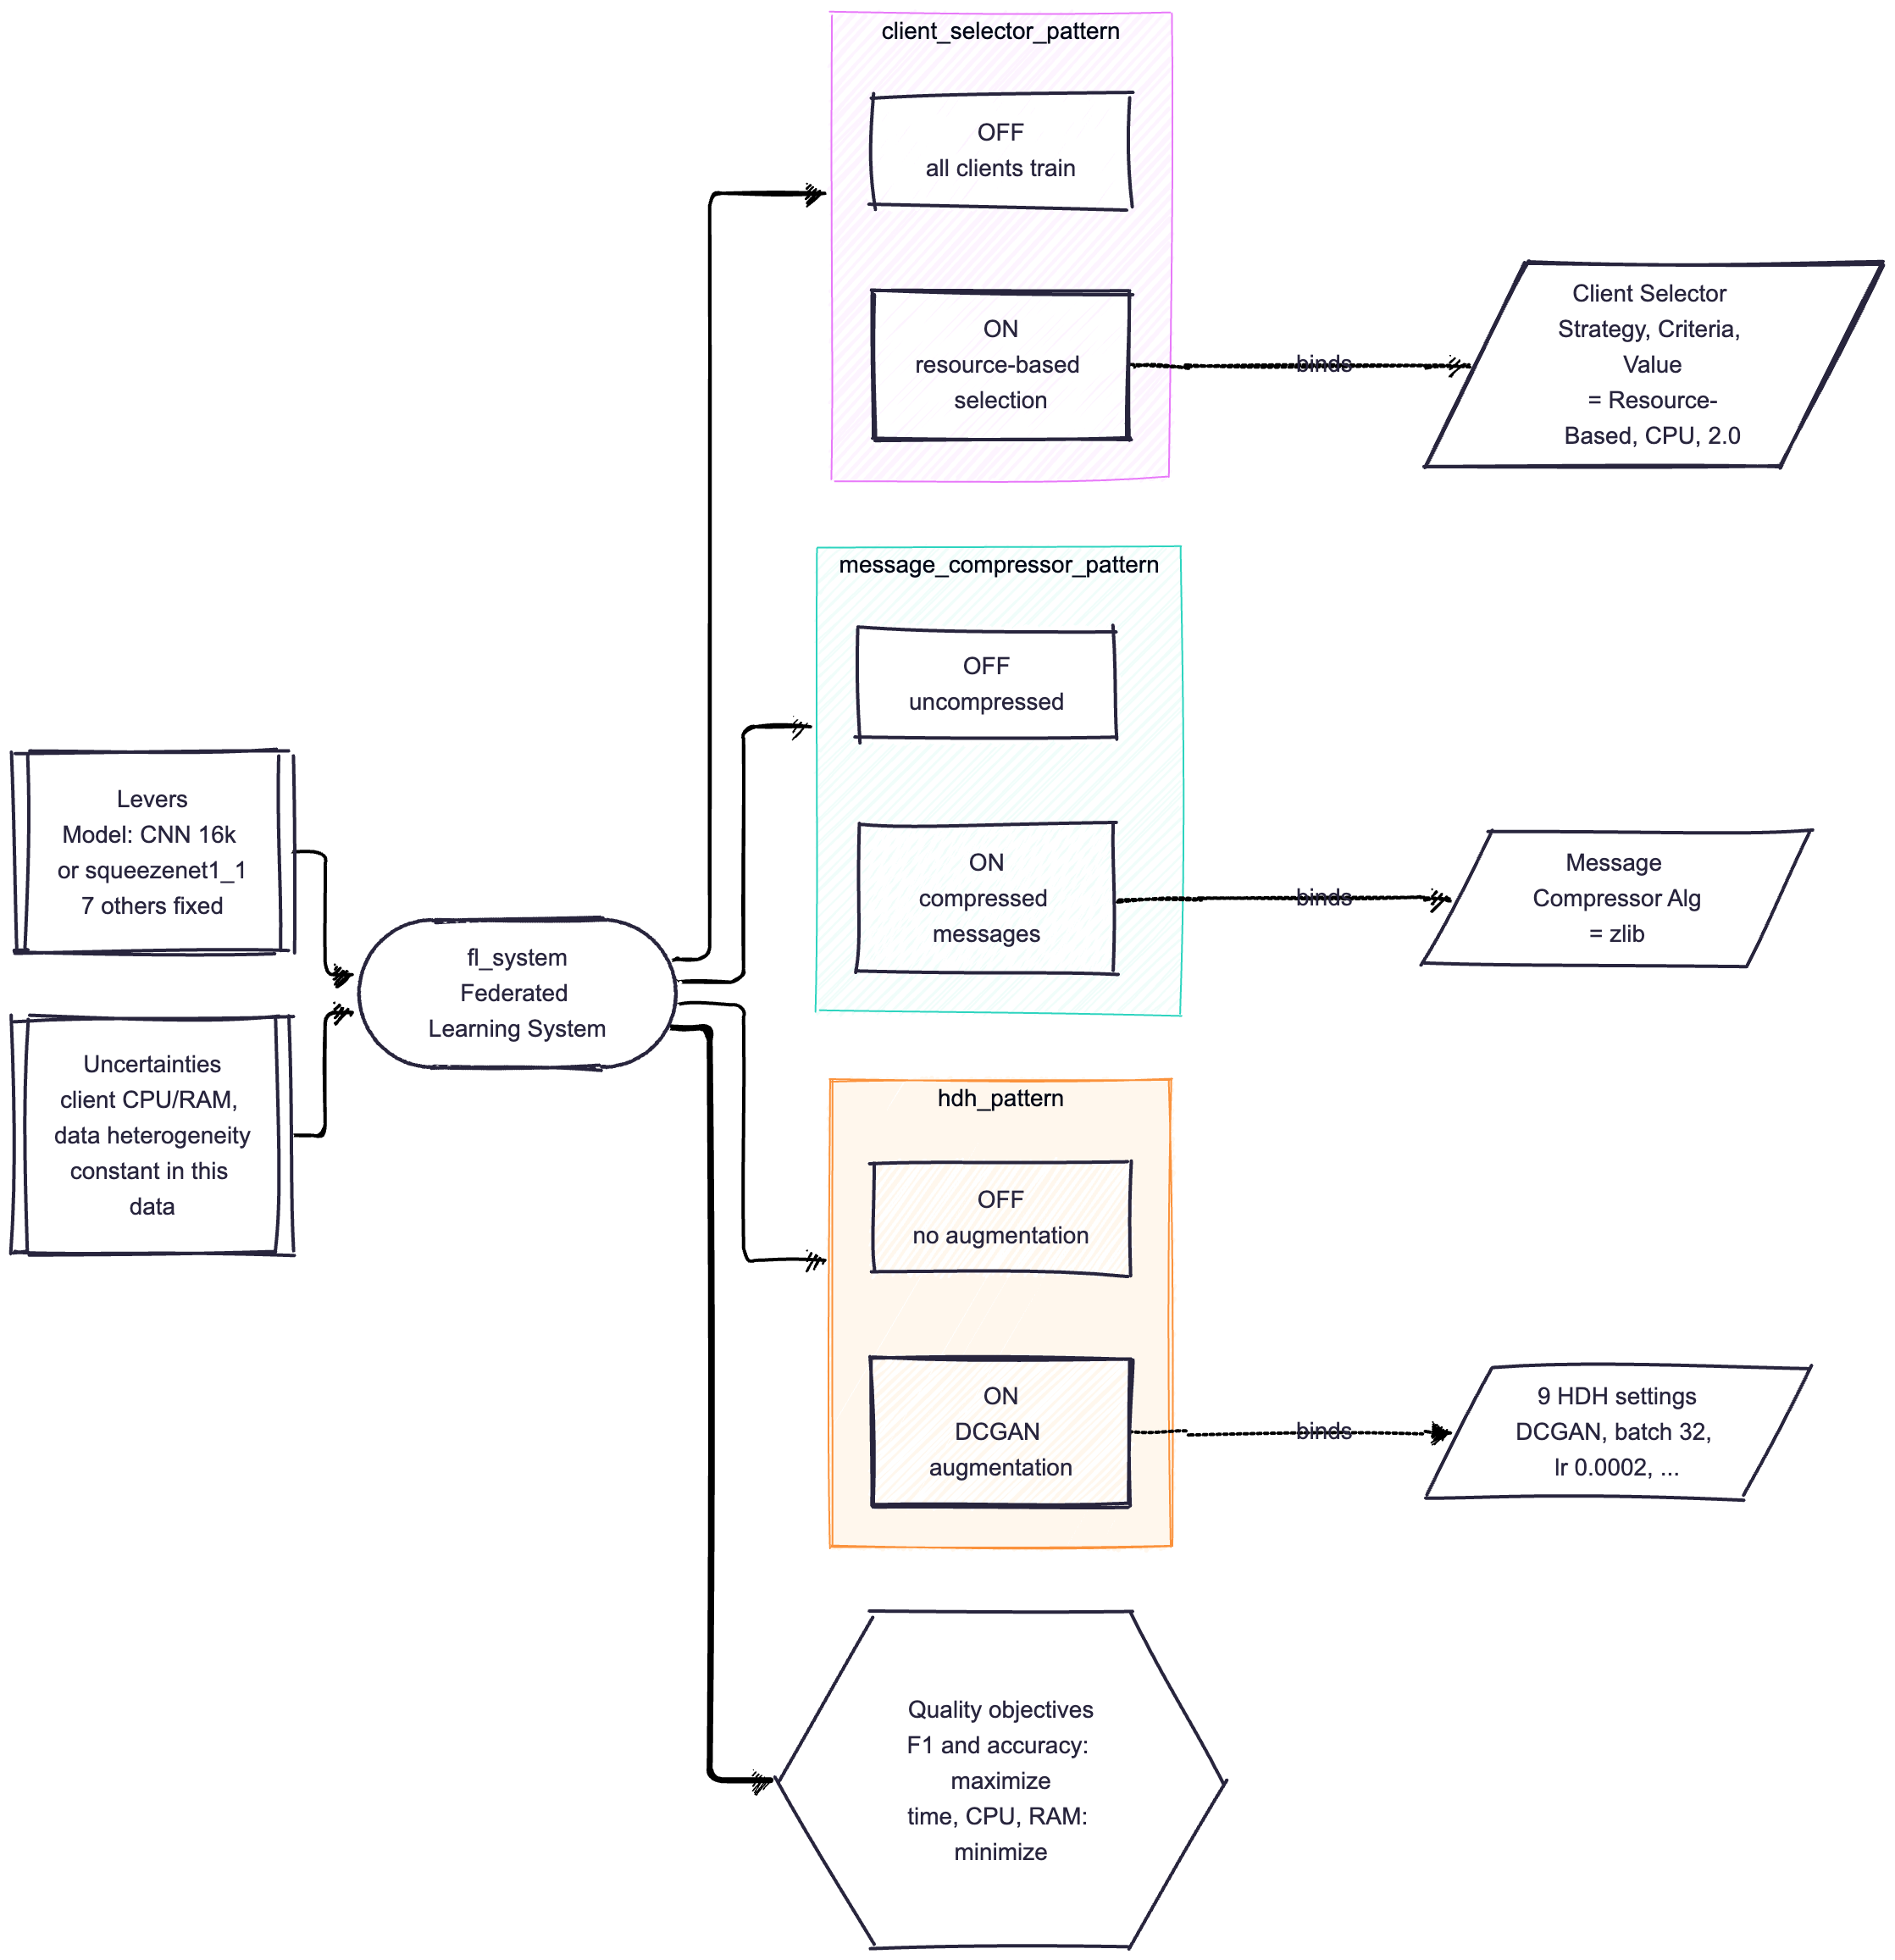

### The design space at a glance

> *Interpretation to be written for this slice.* The corresponding text in `analysis-fl.ipynb` interprets the full dataset and does not apply here.

## 2. Linter Sanity Check (R1-R3, U1)

> *Interpretation to be written for this slice.* The corresponding text in `analysis-fl.ipynb` interprets the full dataset and does not apply here.

In [4]:
issues = SystemLinter().lint(session.sys_def, session.raw_df)
errors = [i for i in issues if i.level == "ERROR"]
warnings_ = [i for i in issues if i.level == "WARNING"]

print(f"Linter findings: {len(errors)} ERROR(s), {len(warnings_)} WARNING(s)")
for issue in issues:
    print(" ", issue)

assert not errors, f"Linter reported ERROR-level issues; fix the spec before proceeding: {errors}"

Linter findings: 0 ERROR(s), 29 WARNING(s)
  [WARNING] Dataspace.ConfigurationIdentification: Configurations defined in JSON but missing in Data: {'OFF,OFF,ON', 'OFF,ON,OFF', 'OFF,OFF,OFF'}
  [WARNING] Dataspace.Configurations: Component 'fl_system' has incomplete policy-combination coverage: 4 of 8 combinations declared (decisions: client_selector_pattern, message_compressor_pattern, hdh_pattern). Missing combinations: OFF,ON,ON, ON,OFF,ON, ON,ON,OFF, ON,ON,ON.
  [WARNING] Dataspace.QualityObjectives: Quality Objective 'RAM Usage Avg Mean' is low-variance: 100.0% of values are concentrated on a single value (threshold 70%).
  [WARNING] System.Components: Parameter 'N Rounds' (Component: fl_system) is low-variance: 100.0% of values are concentrated on a single value (threshold 70%).
  [WARNING] System.Components: Parameter 'Total Clients' (Component: fl_system) is low-variance: 100.0% of values are concentrated on a single value (threshold 70%).
  [WARNING] System.Components: Parameter

### What the linter tells us about the design space

> *Interpretation to be written for this slice.* The corresponding text in `analysis-fl.ipynb` interprets the full dataset and does not apply here.

In [5]:
print(f"Loaded {len(session.raw_df)} experiments.")
session.raw_df.head()

Loaded 10 experiments.


,N Rounds,Total Clients,Model,Dataset,Optimizer,Learning Rate,Batch Size,Epochs,Client 1 ID,Client 1 CPU,...,hdh_pattern,config_id,CPU Mean,RAM Mean,Data Distribution Diversity,Data Persistence Diversity,Alpha Dirichlet Mean,JSD Mean,CPU Usage Avg Mean,RAM Usage Avg Mean
0,10,5,CNN 16k,CIFAR-10,Adam,0.001,64,1,Client 1,3,...,OFF,"ON,OFF,OFF",2.6,2.0,2,1,0.8,NaN,121.150,2.0
1,10,5,CNN 16k,CIFAR-10,Adam,0.001,64,1,Client 1,3,...,OFF,"ON,OFF,OFF",2.6,2.0,2,1,0.8,NaN,125.500,2.0
2,10,5,CNN 16k,CIFAR-10,Adam,0.001,64,1,Client 1,3,...,OFF,"ON,OFF,OFF",2.6,2.0,2,1,0.8,NaN,112.350,2.0
3,10,5,CNN 16k,CIFAR-10,Adam,0.001,64,1,Client 1,3,...,OFF,"ON,OFF,OFF",2.6,2.0,2,1,0.8,NaN,121.800,2.0
4,10,5,CNN 16k,CIFAR-10,Adam,0.001,64,1,Client 1,3,...,OFF,"ON,OFF,OFF",2.6,2.0,2,1,0.8,NaN,116.675,2.0


## 3. Define Tradeoffs (R9)

FL declares 8 quality objectives (6 original + 2 new telemetry objectives from
R8), but only 32 experiment rows. Discretizing all 8 objectives combinatorially
(3 bins each = 3^8 = 6,561 possible tradeoffs) would be intractable and
meaningless at this sample size -- almost every combination would be empty.
We instead discretize the **classic FL tradeoff** into 3 bins per objective:

- **model accuracy**: `final_val_accuracy`, the accuracy of the global model after the last round (maximize);
- **total round time**: `avg_total_time`, the average wall-clock time of a round, training plus communication (minimize). With 10 rounds in every run, total training time is 10x this value.

This mirrors the Gateway Offloading notebook's use of a small, meaningful objective
pair. F1 ranks the runs almost exactly like accuracy (Spearman 0.985 between
`final_val_accuracy` and `best_val_f1`), so it is kept as a robustness check, not a
second target.

In [6]:
# ---- Discretization of the objectives (labels and edges: see the parameters cell)
tradeoffs, schemes = session.create_tradeoffs(
    method='discretization', labels=TRADEOFF_LABELS, edges=TRADEOFF_EDGES
)

print(len(tradeoffs), "possible tradeoffs (regions)")
for scheme in schemes:
    print(f"Objective: {scheme.objective_name}")
    print("  edges:", [scheme.bins[0].min_value] + [b.max_value for b in scheme.bins])
    for b in scheme.bins:
        print(f"  {b.label}: [{b.min_value:.2f}, {b.max_value:.2f}]")


Creating discretization tradeoffs with 3 bins.
9 possible tradeoffs (regions)
Objective: final_val_accuracy
  edges: [0.2123, 0.33613, 0.45997, 0.5838]
  S: [0.21, 0.34]
  M: [0.34, 0.46]
  L: [0.46, 0.58]
Objective: avg_total_time
  edges: [17.261, 195.68233, 374.10367, 552.525]
  S: [17.26, 195.68]
  M: [195.68, 374.10]
  L: [374.10, 552.52]


### The target tradeoffs

> *Interpretation to be written for this slice.* The corresponding text in `analysis-fl.ipynb` interprets the full dataset and does not apply here.

## 4. Data Splitting

We split into train/test sets, stratified by tradeoff membership, to support
both feature scoring (train, Section 7) and box evaluation (test, Sections
8-10).

In [7]:
session.split_data(test_size=0.3, remove_outliers=False, verbose=True)

Data split: 7 train, 3 test.

--- Train Set Tradeoff Counts ---
  S,S: 2 (28.57%)
  M,S: 2 (28.57%)
  L,S: 1 (14.29%)
  L,M: 2 (28.57%)

--- Test Set Tradeoff Counts ---
  S,S: 0 (0.00%)
  M,S: 1 (33.33%)
  L,S: 0 (0.00%)
  L,M: 2 (66.67%)


### Reading the split

> *Interpretation to be written for this slice.* The corresponding text in `analysis-fl.ipynb` interprets the full dataset and does not apply here.

We visually confirm the spread of our metrics. 

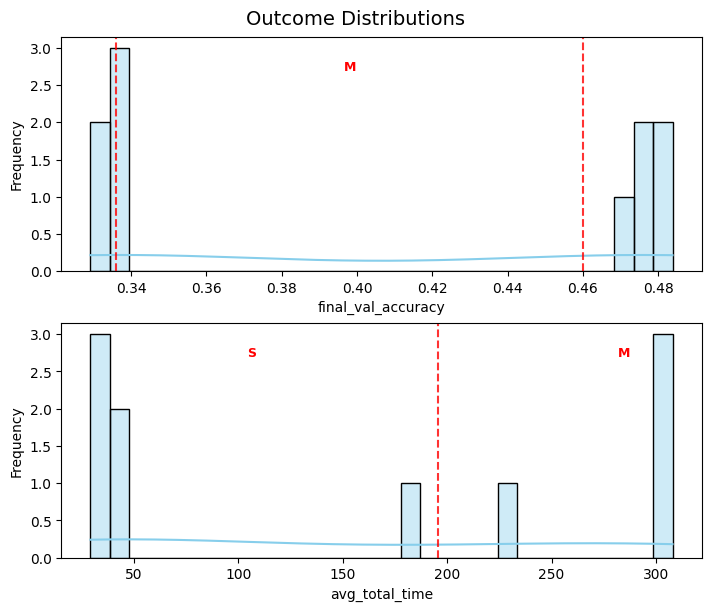

In [8]:
session.show_distributions(figsize=(7,3))
plt.show()

### How to read `S`, `M` and `L`

> *Interpretation to be written for this slice.* The corresponding text in `analysis-fl.ipynb` interprets the full dataset and does not apply here.

We map the tradeoffs onto a 2D space to see their shape and density. Readability enhancements include bottom-aligned legends and bottom-to-top orientation for Y-axis bin labels.

In [9]:
tradeoff_labels = [t.name for t in tradeoffs]
tradeoff_labels

['S-S', 'S-M', 'S-L', 'M-S', 'M-M', 'M-L', 'L-S', 'L-M', 'L-L']

In [10]:
session.get_decisions()

{'client_selector_pattern': Decision(description='Pattern for selecting which clients participate in training', policies={'OFF': PatternPolicy(description='Client selector pattern disabled - all clients participate', parameter_bindings=ParameterBindings(levers={}, uncertainties={}, constraints={})), 'ON': PatternPolicy(description='Client selector pattern enabled - Resource-Based selection', parameter_bindings=ParameterBindings(levers={}, uncertainties={}, constraints={'Client Selector Strategy': 'Resource-Based', 'Client Selector Criteria': 'CPU', 'Client Selector Value': 2.0}))}),
 'message_compressor_pattern': Decision(description='Pattern for compressing messages exchanged between clients and server', policies={'OFF': PatternPolicy(description='Message compressor disabled', parameter_bindings=ParameterBindings(levers={}, uncertainties={}, constraints={})), 'ON': PatternPolicy(description='Message compressor enabled - zlib compression', parameter_bindings=ParameterBindings(levers={}

In [11]:
session.get_policies()

{'OFF,OFF,OFF': SystemConfiguration(name='All Patterns Off', description='No adaptive patterns enabled', pattern_policy_references=[PatternPolicyReference(component='fl_system', decision='client_selector_pattern', policy='OFF'), PatternPolicyReference(component='fl_system', decision='message_compressor_pattern', policy='OFF'), PatternPolicyReference(component='fl_system', decision='hdh_pattern', policy='OFF')], source_file=None, component_policies={}),
 'ON,OFF,OFF': SystemConfiguration(name='Client Selector Only', description='Only client selector pattern enabled', pattern_policy_references=[PatternPolicyReference(component='fl_system', decision='client_selector_pattern', policy='ON'), PatternPolicyReference(component='fl_system', decision='message_compressor_pattern', policy='OFF'), PatternPolicyReference(component='fl_system', decision='hdh_pattern', policy='OFF')], source_file=None, component_policies={}),
 'OFF,ON,OFF': SystemConfiguration(name='Message Compressor Only', descripti

### Decisions, policies and configurations

The two cells above list the same design space at two levels:

| Term | What it is | In this system | Where to see it |
|:---|:---|:---|:---|
| **Decision** | a design choice point for one pattern | `client_selector_pattern`, `message_compressor_pattern`, `hdh_pattern` | `get_decisions()` |
| **Policy** | one option of a decision; it binds values to constraint parameters | `ON` or `OFF` for each decision | `get_decisions()[d].policies` |
| **Configuration** | one policy per decision, i.e. a full system variant | `OFF,OFF,OFF`, `ON,OFF,OFF`, `OFF,ON,OFF`, `OFF,OFF,ON` | `get_policies()`, column `config_id` |

Note that `get_policies()` returns **configurations** (ADEPT calls them system-level policies). Robustness results (Sections 6 and 10) are reported per configuration by default; pass `by='decision'` to report per decision policy instead (e.g. `hdh_pattern:ON`).

#### What else the model contains

| Element | Role | Examples |
|:---|:---|:---|
| **Levers** | design settings not tied to a pattern, controlled by the architect | `Model`, rounds, learning rate |
| **Constraints** | the settings a pattern's `ON` policy fixes; empty when the pattern is OFF, which ADEPT encodes as a separate "not selected" value | `Client Selector Value` = 2.0, `HDH Latent Dim` = 100 |
| **Uncertainties** | environment conditions the architect does not control | client CPU/RAM, data heterogeneity |
| **Quality objectives** | measured outcomes of each run | `final_val_accuracy`, `avg_total_time` (analyzed); 6 others stay in the spec but are excluded from `outcomes_df` (see the warning in Section 3) |

All three parameter kinds are candidate *explanations* of the objectives: Section 7 scores how much each one matters, and Sections 8-9 describe tradeoff regions as ranges over the top-ranked ones.

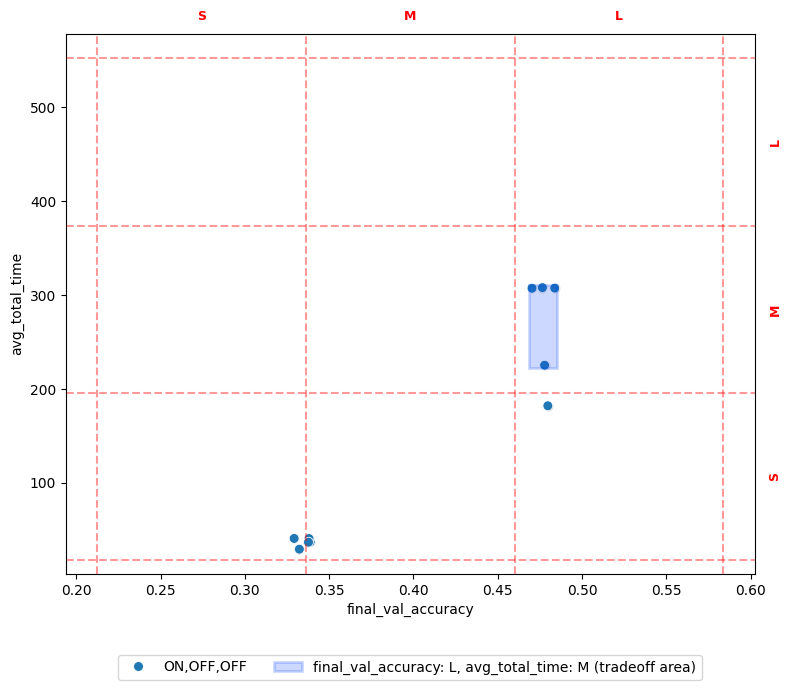

In [12]:
outcome_cols = list(session.outcomes_df.columns)
# Plot the policies for all combinations (pairs) of quality objectives
for x_col, y_col in itertools.combinations(outcome_cols, 2):
    fig = session.show_quality_objective_space(
        x_col, y_col,
        highlight_policies=session.get_policies(), 
        highlight_tradeoffs=[session.get_tradeoff(tradeoffs[7].name)],
        # show_overall=True,
        subset='all',
        cmap='tab10', 
        alpha=1.0,
        figsize=(8, 7),
        s=50,
        title=""
    )
    # fig.savefig(f'fl-quality_objective_space_{x_col}_{y_col}.png', dpi=500)
    plt.show()

### Reading the objective space

> *Interpretation to be written for this slice.* The corresponding text in `analysis-fl.ipynb` interprets the full dataset and does not apply here.

## 5. Per-Decision Contingency Analysis (R9)

For each of FL's 3 composed pattern decisions (`client_selector_pattern`,
`message_compressor_pattern`, `hdh_pattern`), we compute the contingency
between policy choice and tradeoff outcome, and identify deterministic
policies and tradeoffs each decision exclusively unlocks.

In [13]:
session.get_decisions()

{'client_selector_pattern': Decision(description='Pattern for selecting which clients participate in training', policies={'OFF': PatternPolicy(description='Client selector pattern disabled - all clients participate', parameter_bindings=ParameterBindings(levers={}, uncertainties={}, constraints={})), 'ON': PatternPolicy(description='Client selector pattern enabled - Resource-Based selection', parameter_bindings=ParameterBindings(levers={}, uncertainties={}, constraints={'Client Selector Strategy': 'Resource-Based', 'Client Selector Criteria': 'CPU', 'Client Selector Value': 2.0}))}),
 'message_compressor_pattern': Decision(description='Pattern for compressing messages exchanged between clients and server', policies={'OFF': PatternPolicy(description='Message compressor disabled', parameter_bindings=ParameterBindings(levers={}, uncertainties={}, constraints={})), 'ON': PatternPolicy(description='Message compressor enabled - zlib compression', parameter_bindings=ParameterBindings(levers={}

FL decisions: ['client_selector_pattern', 'message_compressor_pattern', 'hdh_pattern']
Analyzing Decision: client_selector_pattern


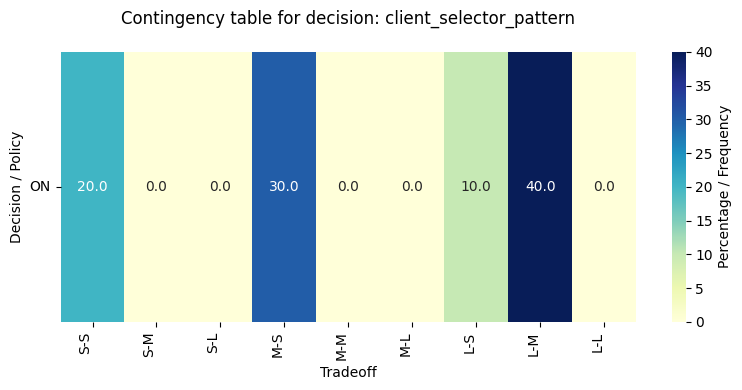

Analyzing Decision: message_compressor_pattern


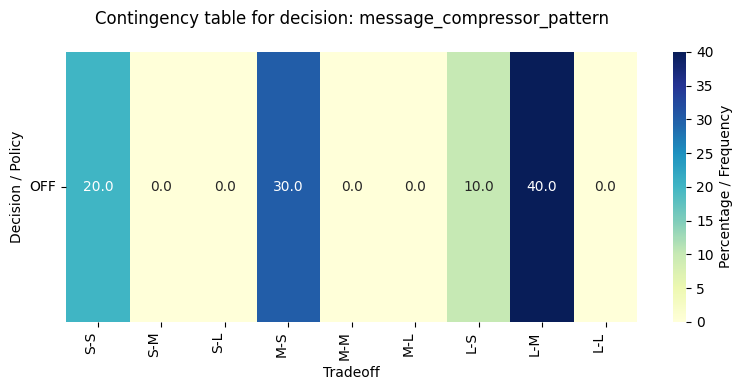

Analyzing Decision: hdh_pattern


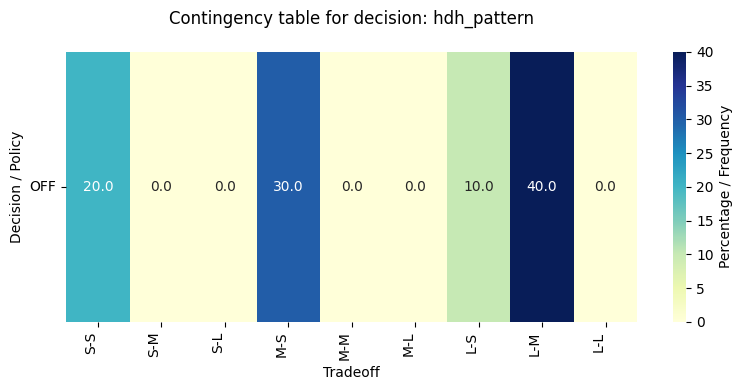

In [14]:
decisions = list(session.get_decisions().keys())
print("FL decisions:", decisions)

for decision_key in decisions:
    print(f"Analyzing Decision: {decision_key}")
    session.show_policy_contingency(
        decision_key,
        type='heatmap',
        subset='all',
        title=f"Contingency table for decision: {decision_key}",
        figsize=(8, 4)
    )
    plt.show()

In [15]:
print("Deterministic policies (policies that consistently result in a single specific tradeoff)")
for decision_key in decisions:
    print("---" * 10)
    print("Decision:", decision_key)
    for policy, tradeoff in session.get_deterministic_policies(decision_key):
        print("* Policy:", policy, "--> Tradeoff:", tradeoff)

Deterministic policies (policies that consistently result in a single specific tradeoff)
------------------------------
Decision: client_selector_pattern
------------------------------
Decision: message_compressor_pattern
------------------------------
Decision: hdh_pattern


In [16]:
print("Exclusive tradeoffs (tradeoffs reachable through only one decision's policy)")
for decision_key in decisions:
    print("---" * 10)
    print("Decision:", decision_key)
    for policy, tradeoff in session.get_exclusive_tradeoffs(decision_key):
        print("* Tradeoff:", tradeoff, "--> Decision:", decision_key, "[Policy:", policy, "]")

Exclusive tradeoffs (tradeoffs reachable through only one decision's policy)
------------------------------
Decision: client_selector_pattern
* Tradeoff: S-S --> Decision: client_selector_pattern [Policy: ON ]
* Tradeoff: M-S --> Decision: client_selector_pattern [Policy: ON ]
* Tradeoff: L-S --> Decision: client_selector_pattern [Policy: ON ]
* Tradeoff: L-M --> Decision: client_selector_pattern [Policy: ON ]
------------------------------
Decision: message_compressor_pattern
* Tradeoff: S-S --> Decision: message_compressor_pattern [Policy: OFF ]
* Tradeoff: M-S --> Decision: message_compressor_pattern [Policy: OFF ]
* Tradeoff: L-S --> Decision: message_compressor_pattern [Policy: OFF ]
* Tradeoff: L-M --> Decision: message_compressor_pattern [Policy: OFF ]
------------------------------
Decision: hdh_pattern
* Tradeoff: S-S --> Decision: hdh_pattern [Policy: OFF ]
* Tradeoff: M-S --> Decision: hdh_pattern [Policy: OFF ]
* Tradeoff: L-S --> Decision: hdh_pattern [Policy: OFF ]
* Trad

## 6. Robustness Analysis (Quantifying Stability)
While contingency tells us *how often* we succeed, robustness tells us *how stable* that success is when parameters vary. We use two complementary metrics:
- **STARR (Success Rate)**: The percentage of points within a policy that meet the target requirements. Higher is better.
- **REGRET (Risk)**: The standardized distance from the closest successful point. It measures 'how bad' a failure is. Lower is better.

In [17]:
metric = 'starr' #'starr' 'regret'

In [18]:
base_robustness_matrix = session.get_robustness_report(metric=metric, subset='test') 
base_robustness_matrix # Test

,S-S,S-M,S-L,M-S,M-M,M-L,L-S,L-M,L-L
policy,,,,,,,,,
"ON,OFF,OFF",0.0,0.0,0.0,0.333333,0.0,0.0,0.0,0.666667,0.0


Robustness Ranking for Tradeoff: S-S
  1. ON,OFF,OFF: 20% success
  Top Policy -> ON,OFF,OFF - Starr: 0.2000 - Regret: 1.0688
Robustness Ranking for Tradeoff: S-M
  1. ON,OFF,OFF: 0% success
  Top Policy -> ON,OFF,OFF - Starr: 0.0000 - Regret: 1.7317
Robustness Ranking for Tradeoff: S-L
  1. ON,OFF,OFF: 0% success
  Top Policy -> ON,OFF,OFF - Starr: 0.0000 - Regret: 2.7239
Robustness Ranking for Tradeoff: M-S
  1. ON,OFF,OFF: 30% success
  Top Policy -> ON,OFF,OFF - Starr: 0.3000 - Regret: 0.4060
Robustness Ranking for Tradeoff: M-M
  1. ON,OFF,OFF: 0% success
  Top Policy -> ON,OFF,OFF - Starr: 0.0000 - Regret: 0.8792
Robustness Ranking for Tradeoff: M-L
  1. ON,OFF,OFF: 0% success
  Top Policy -> ON,OFF,OFF - Starr: 0.0000 - Regret: 2.1308
Robustness Ranking for Tradeoff: L-S
  1. ON,OFF,OFF: 10% success
  Top Policy -> ON,OFF,OFF - Starr: 0.1000 - Regret: 1.2081
Robustness Ranking for Tradeoff: L-M
  1. ON,OFF,OFF: 40% success
  Top Policy -> ON,OFF,OFF - Starr: 0.4000 - Regret: 1.1

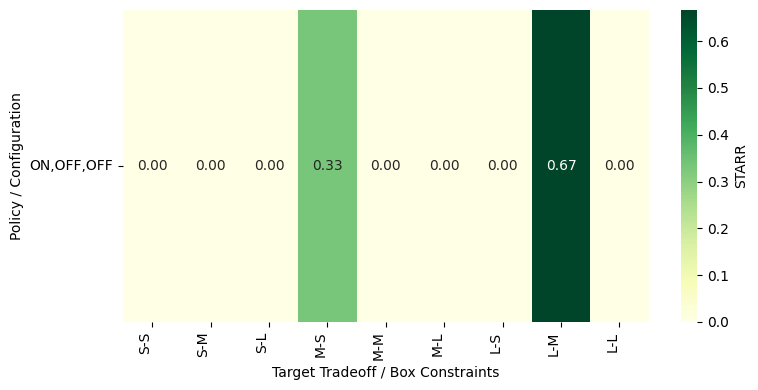

In [19]:
for tradeoff in session.get_tradeoffs():
    print(f"Robustness Ranking for Tradeoff: {tradeoff.name}")
    ranking = session.get_policy_robustness_ranking(tradeoff.name, metric='starr')
    for i, (pol, val) in enumerate(ranking[:3]):
        print(f"  {i+1}. {pol}: {val:.0%} success")
    
    if ranking:
        top_pol = ranking[0][0]
        starr = session.compute_robustness(top_pol, tradeoff.name, metric='starr')
        regret = session.compute_robustness(top_pol, tradeoff.name, metric='regret')
        print(f"  Top Policy -> {top_pol} - Starr: {starr.get('value', 0.0):.4f} - Regret: {regret.get('value', 0.0):.4f}")

if metric == 'starr':
    print("Overall Robustness Heatmap (STARR):")
    session.show_robustness_heatmap(matrix=base_robustness_matrix, metric='starr', figsize=(8,4))
    plt.show()

if metric == 'regret':
    print("Overall Robustness Heatmap (REGRET):")
    session.show_robustness_heatmap(matrix=base_robustness_matrix, metric='regret', figsize=(8,4), title=metric)
    plt.show()

## 7. Feature Importance & Key-Parameter Selection (R6)

> *Interpretation to be written for this slice.* The corresponding text in `analysis-fl.ipynb` interprets the full dataset and does not apply here.

In [20]:
scores_df = session.compute_feature_scores(
    use_smart_correlation=True,
    include_constraints=True,
    subset='train'
)
scores_df

Scoring features for outcome: final_val_accuracy (on subset: train)
Original features (numerically encoded): ['N Rounds', 'Total Clients', 'Model', 'Dataset', 'Optimizer', 'Learning Rate', 'Batch Size', 'Epochs', 'Client Selector Strategy', 'Client Selector Criteria', 'Client Selector Value', 'Message Compressor Alg', 'HDH Batch Size', 'HDH Beta 1', 'HDH Beta 2', 'HDH Discriminator', 'HDH Epochs', 'HDH Generator', 'HDH Learning Rate', 'HDH Latent Dim', 'HDH Optimizer', 'CPU Mean', 'RAM Mean', 'Alpha Dirichlet Mean', 'JSD Mean', 'Data Distribution Diversity', 'Data Persistence Diversity']
Features selected: ['N Rounds', 'Total Clients', 'Model', 'Dataset', 'Optimizer', 'Learning Rate', 'Batch Size', 'Epochs', 'Client Selector Strategy', 'Client Selector Criteria', 'Client Selector Value', 'Message Compressor Alg', 'HDH Batch Size', 'HDH Beta 1', 'HDH Beta 2', 'HDH Discriminator', 'HDH Epochs', 'HDH Generator', 'HDH Learning Rate', 'HDH Latent Dim', 'HDH Optimizer', 'CPU Mean', 'RAM Mean

,final_val_accuracy,avg_total_time
Alpha Dirichlet Mean,0.0,0.0
Batch Size,0.0,0.0
CPU Mean,0.0,0.0
Client Selector Criteria,0.0,0.0
Client Selector Strategy,0.0,0.0
Client Selector Value,0.0,0.0
Data Distribution Diversity,0.0,0.0
Data Persistence Diversity,0.0,0.0
Dataset,0.0,0.0
Epochs,0.0,0.0


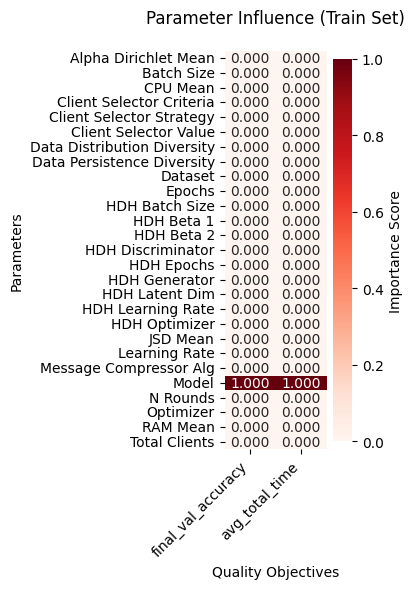

In [21]:
session.show_feature_heatmap(scores_df, title="Parameter Influence (Train Set)", figsize=(4,6))
plt.show()

### R6 regression guard

All 13 of FL's existing pattern parameters must appear in the
feature-importance ranking output. If a future edit reintroduces the
`include_constraints=False` default at this call site, this assertion -- not
silent output -- is what fails `nbconvert --execute`.

In [22]:
FL_PATTERN_PARAMETERS = [
    "Client Selector Strategy", "Client Selector Criteria", "Client Selector Value",
    "Message Compressor Alg",
    "HDH Batch Size", "HDH Beta 1", "HDH Beta 2", "HDH Discriminator", "HDH Epochs",
    "HDH Generator", "HDH Learning Rate", "HDH Latent Dim", "HDH Optimizer",
]
assert len(FL_PATTERN_PARAMETERS) == 13

missing = [p for p in FL_PATTERN_PARAMETERS if p not in scores_df.index]
assert not missing, (
    f"compute_feature_scores(include_constraints=True) dropped pattern parameters: {missing}"
)
print(f"All {len(FL_PATTERN_PARAMETERS)} FL pattern parameters are present "
      f"in the feature-importance ranking (R6 verified).")

All 13 FL pattern parameters are present in the feature-importance ranking (R6 verified).


In [23]:
weighted_features = session.get_weighted_feature_ranking(scores_df)
print("Weighted feature ranking:", weighted_features)

# Categorical parameters (e.g. Model) and optional ones (NaN = pattern not selected)
# are encoded numerically by ADEPT, so every ranked parameter can go to discovery.
# Model dominates the scores (~0.9), so a low threshold (0.03) is needed to also keep
# the pattern parameters with a secondary influence: 'HDH Batch Size' (stands for HDH
# ON/OFF) and 'Client Selector Criteria' (client selector ON/OFF).
key_parameters = session.select_top_k_parameters(
    scores_df, index_order=weighted_features, threshold=0.03, k=None
)
print("Key parameters (for scenario discovery):", key_parameters)

Weighted feature ranking: ['Model']
Key parameters (for scenario discovery): ['Model']


## 8. Scenario Discovery: PRIM (R9)

PRIM searches, for each tradeoff region, a box over the key parameters from Section 7
(`Model` and the representatives of the client selector and HDH patterns). Box limits
are printed with `readable_limits()`: categorical parameters as sets of categories,
and `includes_na` when the box also covers a pattern's "not selected" (OFF) state.

KTD8's `analyzer_fi` -> `analyzer` fix in `_discover_single_prim`
(`adept/core/session.py`) is required for this cell to run at all: with
`standardize=True`, the unfixed method referenced the undefined name
`analyzer_fi` and raised `NameError` before computing any box.

In [24]:
# Scenario discovery uses the key parameters selected in Section 7 (threshold=0.03).
print("Key parameters (for scenario discovery):", key_parameters)

Key parameters (for scenario discovery): ['Model']


In [25]:
prim_boxes = []
non_empty_tradeoffs = session.get_tradeoffs(non_empty=True)
for tradeoff in non_empty_tradeoffs:
    print("---" * 10)
    print(f"Discovering scenarios for: {tradeoff.name}")
    boxes = session.discover_scenarios(
        tradeoff.name, method='prim',
        threshold=0.8,
        standardize=True,
        parameters=key_parameters
    )
    non_empty_boxes = [b for b in boxes if not b.is_empty()]
    if non_empty_boxes:
        best_box = non_empty_boxes[0]
        print(f"* Key Rules: {best_box.readable_limits()}")
        print(f"* Metrics: {best_box.metrics}")
        prim_boxes.append(best_box)
    else:
        print("--> No scenarios discovered.")

print(f"\n{len(prim_boxes)} non-empty PRIM box(es) discovered across "
      f"{len(non_empty_tradeoffs)} non-empty tradeoffs.")

------------------------------
Discovering scenarios for: S-S
Running PRIM discovery for: S-S ...
Instances satisfying property: False    5
True     2
Name: count, dtype: int64
Total instances: (7, 1)
Running PRIM ... rhodium
2 possible boxes
--> No scenarios discovered.
------------------------------
Discovering scenarios for: M-S
Running PRIM discovery for: M-S ...
Instances satisfying property: False    5
True     2
Name: count, dtype: int64
Total instances: (7, 1)
Running PRIM ... rhodium
2 possible boxes
* Key Rules: {'Model': {'in': ['CNN 16k']}}
* Metrics: {'density': 1.0, 'coverage': 1.0, 'population_prevalence': 0.2857142857142857, 'lift': 0.7142857142857143, 'samples_in_box': 1.0, 'targets_in_box': 1.0}
------------------------------
Discovering scenarios for: L-S
Running PRIM discovery for: L-S ...
Instances satisfying property: False    6
True     1
Name: count, dtype: int64
Total instances: (7, 1)
Running PRIM ... rhodium
2 possible boxes
--> No scenarios discovered.
-----

/Users/adiazpace/opt/anaconda3/envs/perfmodels/lib/python3.11/site-packages/prim/prim_box.py:415: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.peeling_trajectory = pd.concat([self.peeling_trajectory, pd.DataFrame([stats])],
/Users/adiazpace/opt/anaconda3/envs/perfmodels/lib/python3.11/site-packages/prim/prim_box.py:415: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.peeling_trajectory = pd.concat([self.peeling_trajectory, pd.DataFrame([stats])],
/Users/adiazpace/opt/anaconda3/envs/perf

In [26]:
boxes_to_keep = []
print("Summary of PRIM boxes:")
for idx, box in enumerate(prim_boxes):
    if not box.is_empty():
        lift = box.metrics.get('lift', None)
        print(f" {idx+1}. For tradeoff {box.target_tradeoff} ({box.target_tradeoff_labels}): lift={lift:.2f} \n\t{box.readable_limits()}")
        # print(box.actual_limits)
        boxes_to_keep.append(box)
    else:
        solutions = box.metrics.get('targets_in_box', 0)
        print(f" Skipping empty box. For tradeoff {box.target_tradeoff} ({box.target_tradeoff_labels}) {solutions}")
prim_boxes = boxes_to_keep

Summary of PRIM boxes:
 1. For tradeoff M-S (M,S): lift=0.71 
	{'Model': {'in': ['CNN 16k']}}
 2. For tradeoff L-M (L,M): lift=0.71 
	{'Model': {'in': ['squeezenet1_1']}}


### Interpreting the PRIM boxes

> *Interpretation to be written for this slice.* The corresponding text in `analysis-fl.ipynb` interprets the full dataset and does not apply here.

In [27]:
# Print prim_boxes to a JSON file
# with open('prim_boxes-fl.json', 'w') as f:
#     json_boxes = [box.model_dump() for box in prim_boxes]
#     json.dump(json_boxes, f, indent=4)


## 9. Global Discovery: CART (R9)

Using decision trees, we partition the entire design space into regions,
providing a global map of the most likely outcomes for any input
combination.

In [28]:
cart_boxes_all = session.discover_scenarios(method='cart', standardize=True, parameters=key_parameters)
cart_boxes = []
for idx, box in enumerate(cart_boxes_all):
    if not box.is_empty():
        lift = box.metrics.get('lift', None)
        lift_str = f"{lift:.2f}" if lift is not None else "n/a"
        print(f" {idx+1}. For tradeoff {box.target_tradeoff} ({box.target_tradeoff_labels}): "
              f"lift={lift_str} \n\t{box.readable_limits()}")
        cart_boxes.append(box)
    else:
        solutions = box.metrics.get('targets_in_box', 0)
        print(f" Skipping empty box. For tradeoff {box.target_tradeoff} "
              f"({box.target_tradeoff_labels}) {solutions}")

print(f"\n{len(cart_boxes)} non-empty CART box(es) discovered.")

Running CART global discovery for all tradeoff combinations ...
 1. For tradeoff M-S (M,S): lift=0.71 
	{'Model': {'in': ['CNN 16k']}}
 2. For tradeoff L-M (L,M): lift=0.71 
	{'Model': {'in': ['squeezenet1_1']}}

2 non-empty CART box(es) discovered.


### Interpreting the CART boxes

> *Interpretation to be written for this slice.* The corresponding text in `analysis-fl.ipynb` interprets the full dataset and does not apply here.

In [29]:
# Print cart_boxes to a JSON file
# with open('cart_boxes-fl.json', 'w') as f:
#     json_boxes = [box.model_dump() for box in cart_boxes]
#     json.dump(json_boxes, f, indent=4)


## 10. Potential Robustness Improvements (What-If Analysis)
Finally, we simulate the impact of applying discovered scenario constraints. We compare **Baseline Robustness** vs. **Improved Robustness** to quantify the value of the discovered 'Operating Envelopes' for each policy.

In [30]:
# Rows are policy groups. With several decisions, 'policy' is ambiguous (plain ON/OFF repeats
# across decisions), so the grouping is explicit: by='configuration' (default, one row per
# configuration such as 'OFF,OFF,ON'), by='decision' (rows like 'hdh_pattern:ON') or
# by='<decision>'. base_robustness_matrix must be computed with the same `by`.
# See docs/robustness_policy_grouping.md.
combined_df = session.get_robustness_results(prim_boxes, cart_boxes, baseline=base_robustness_matrix, by='configuration')
# combined_df.to_csv('results-fl.csv', index=False, decimal=',')
combined_df

,method,policy,target,L-L,L-M,L-S,M-L,M-M,M-S,S-L,S-M,S-S
0,test set,"ON,OFF,OFF",,0.0,0.666667,0.0,0.0,0.0,0.333333,0.0,0.0,0.0
1,prim,"ON,OFF,OFF",L-M,0.0,1.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
2,prim,"ON,OFF,OFF",M-S,0.0,0.000000,0.0,0.0,0.0,1.000000,0.0,0.0,0.0
3,cart,"ON,OFF,OFF",L-M,0.0,1.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
4,cart,"ON,OFF,OFF",M-S,0.0,0.000000,0.0,0.0,0.0,1.000000,0.0,0.0,0.0


In [31]:
prim_box_list = session.align_boxes_to_tradeoffs(prim_boxes) # PRIM

prim_robustness_improvement_matrix = session.get_policy_robustness_improvement_matrix(prim_box_list, metric=metric, subset='test')
prim_robustness_improvement_matrix

,S-S,S-M,S-L,M-S,M-M,M-L,L-S,L-M,L-L
"ON,OFF,OFF",None,None,None,1.0,None,None,None,1.0,None


In [32]:
session.get_tradeoff_coverage_matrix(prim_boxes, subset='test')

,S-S,S-M,S-L,M-S,M-M,M-L,L-S,L-M,L-L
M-S,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
L-M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [33]:
cart_box_list = session.align_boxes_to_tradeoffs(cart_boxes) # CART

cart_robustness_improvement_matrix = session.get_policy_robustness_improvement_matrix(cart_box_list, metric=metric, subset='test')
cart_robustness_improvement_matrix

,S-S,S-M,S-L,M-S,M-M,M-L,L-S,L-M,L-L
"ON,OFF,OFF",None,None,None,1.0,None,None,None,1.0,None


In [34]:
session.get_tradeoff_coverage_matrix(cart_boxes, subset='test')

,S-S,S-M,S-L,M-S,M-M,M-L,L-S,L-M,L-L
M-S,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
L-M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


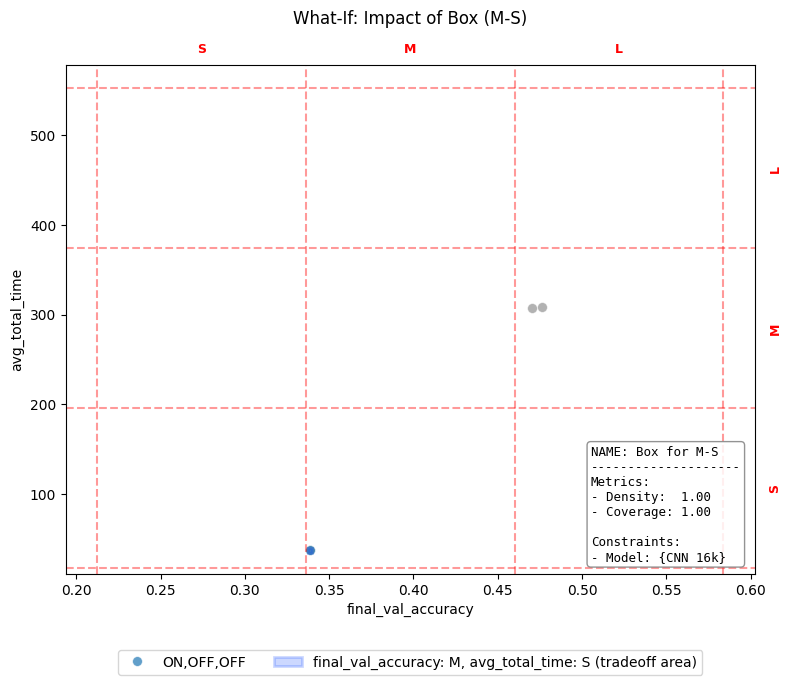

In [35]:
# Visualization of an example box: the first tradeoff that has a CART box
# (cart_box_list is aligned with `tradeoffs`; tradeoffs without a box hold None)
example = next(((box, t) for box, t in zip(cart_box_list, tradeoffs) if box is not None), None)
if example is None:
    print("No CART box to visualize.")
else:
    example_box, example_tradeoff = example
    for x_col, y_col in itertools.combinations(outcome_cols, 2):
        session.show_box_impact_objective_space(
            box=example_box,
            x_metric=x_col, 
            y_metric=y_col,
            tradeoff=session.get_tradeoff(example_tradeoff.name),
            show_box_summary=True,
            subset='test',
            cmap='tab10', 
            alpha=0.7,
            figsize=(8, 7),
            s=50
        )
        plt.show()


/var/folders/tx/dmzj44qn2s92dyzxj_nrc82c0000gn/T/ipykernel_95544/390917906.py:3: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/var/folders/tx/dmzj44qn2s92dyzxj_nrc82c0000gn/T/ipykernel_95544/390917906.py:3: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


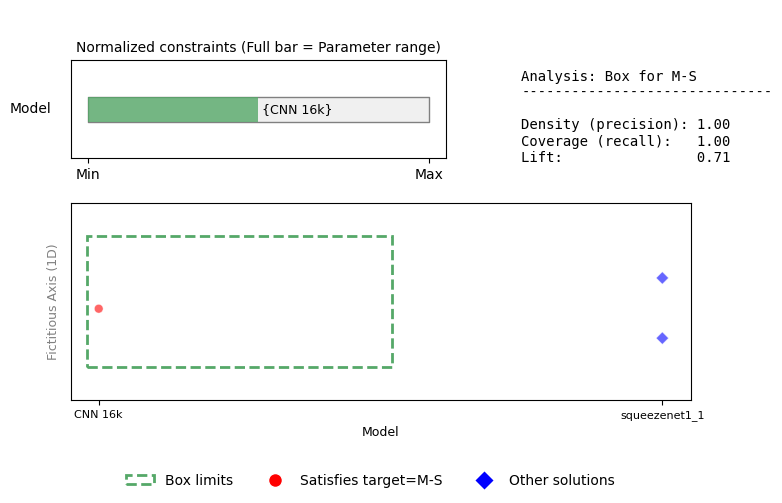

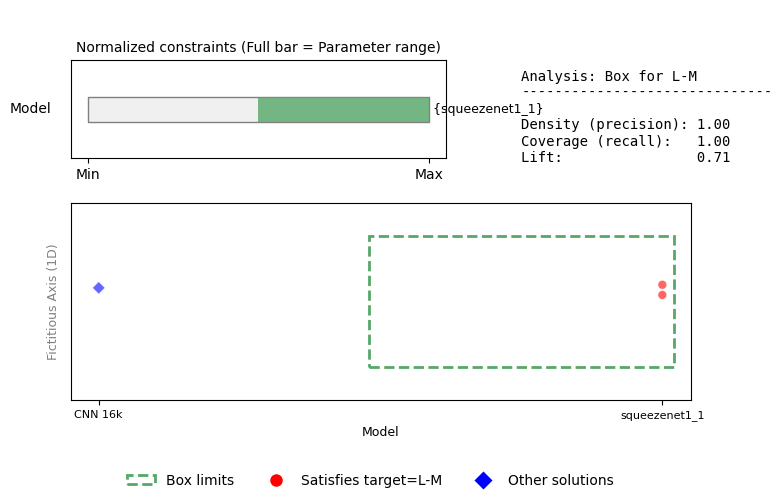

In [36]:
for box in prim_boxes: # Inspect PRIM boxes
    fig = session.show_box_diagnostics(box, subset='test', show_policies=False, figsize=(8,5), title=" ") #, palette='tab10')
    fig.show()

## 11. Box Diagnostics (R9) and N/A-Hatching Check (R10)

We first visualize the first non-empty discovered box (PRIM or CART). We then
look for a box that also covers the "not selected" state of some optional
parameter (`box.includes_na`), which the diagnostics plot draws as a hatched
N/A region (R10).

For FL, a box covers the "not selected" state when it describes runs where a
pattern is OFF, e.g. a limit on `Client Selector Criteria` that includes its
"not selected" value. The cell below renders the first such box, or reports
explicitly that none was found.

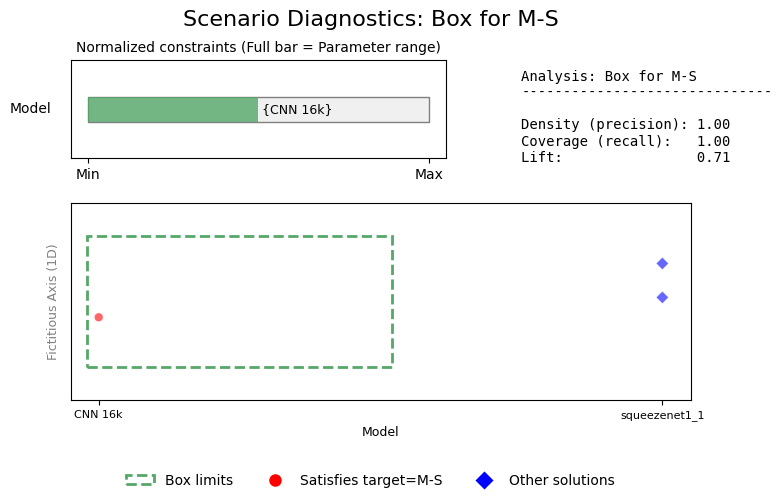

In [37]:
all_boxes = prim_boxes + cart_boxes

if all_boxes:
    first_box = all_boxes[0]
    fig = session.show_box_diagnostics(box=first_box, subset='test', show_policies=False, figsize=(8, 5))
    plt.show()
else:
    print("No non-empty boxes were discovered by PRIM or CART; skipping box diagnostics.")

In [38]:
# Boxes record which optional parameters they cover in the "not selected" state
# (box.includes_na); readable_limits() marks those parameters with includes_na.
na_hatching_box = next(
    ((box, param) for box in all_boxes for param, covered in box.includes_na.items() if covered),
    None
)

if na_hatching_box:
    box, param_name = na_hatching_box
    print(f"R10: box for {box.target_tradeoff} also covers '{param_name}' = not selected: "
          f"{box.readable_limits()[param_name]}. Rendering N/A-hatching diagnostics:")
    fig = session.show_box_diagnostics(box=box, subset='test', show_policies=False, figsize=(8, 5))
    plt.show()
else:
    print("R10: no PRIM/CART box discovered in this run covers an optional parameter's "
          "'not selected' state, so there is no N/A region to hatch.")

R10: no PRIM/CART box discovered in this run covers an optional parameter's 'not selected' state, so there is no N/A region to hatch.


/var/folders/tx/dmzj44qn2s92dyzxj_nrc82c0000gn/T/ipykernel_95544/390917906.py:3: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/var/folders/tx/dmzj44qn2s92dyzxj_nrc82c0000gn/T/ipykernel_95544/390917906.py:3: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


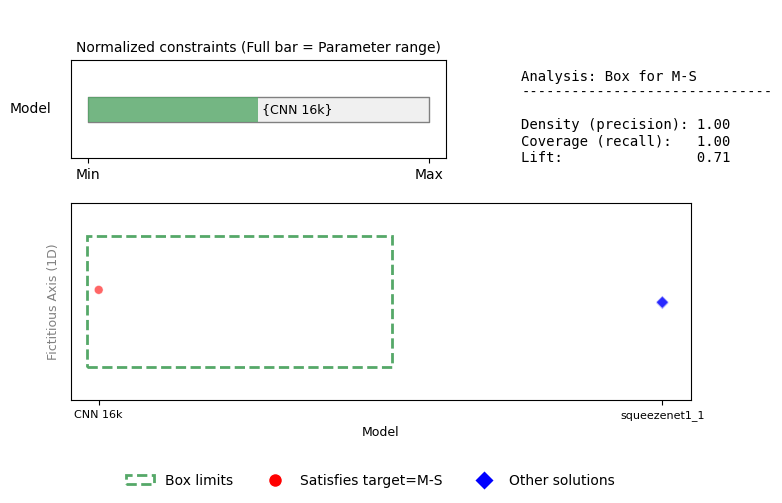

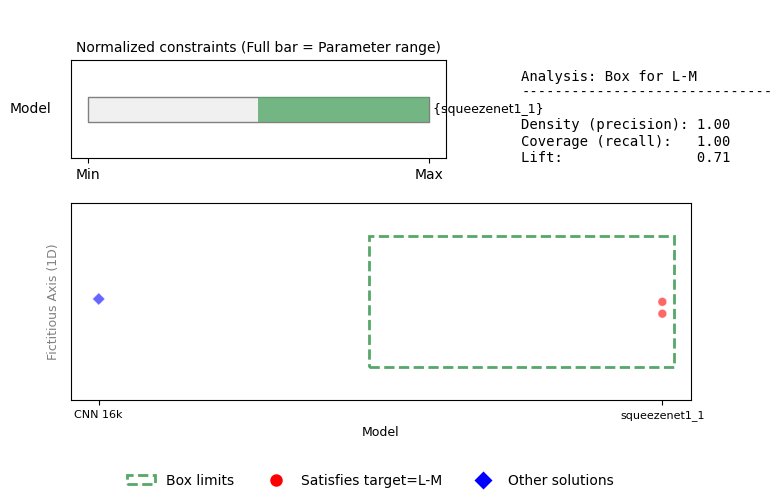

In [39]:
for box in prim_boxes: # Inspect PRIM boxes
    fig = session.show_box_diagnostics(box, subset='test', show_policies=False, figsize=(8,5), title=" ") #, palette='tab10')
    fig.show()

/var/folders/tx/dmzj44qn2s92dyzxj_nrc82c0000gn/T/ipykernel_95544/534013300.py:3: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


/var/folders/tx/dmzj44qn2s92dyzxj_nrc82c0000gn/T/ipykernel_95544/534013300.py:3: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


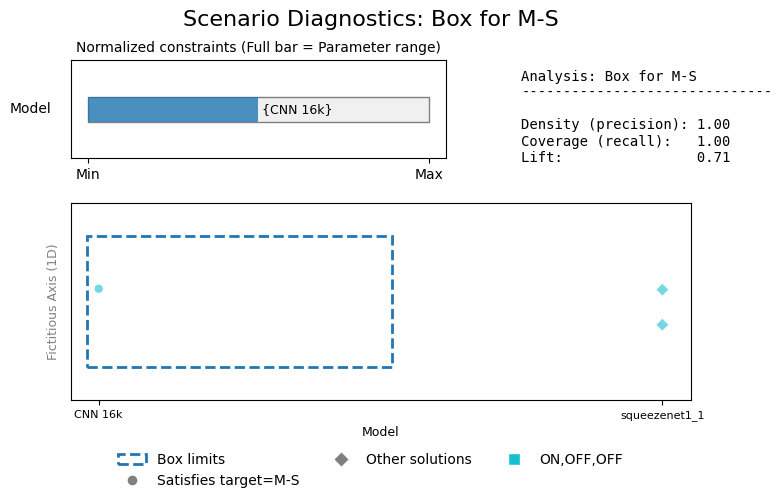

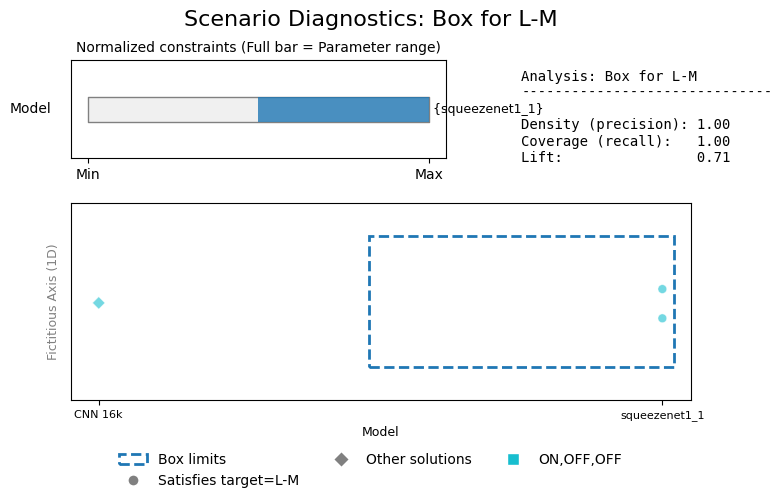

In [40]:
for box in cart_boxes: # Inspect CART boxes
    fig = session.show_box_diagnostics(box, subset='test', show_policies=True, figsize=(8,5)) #, palette='tab10')
    fig.show()

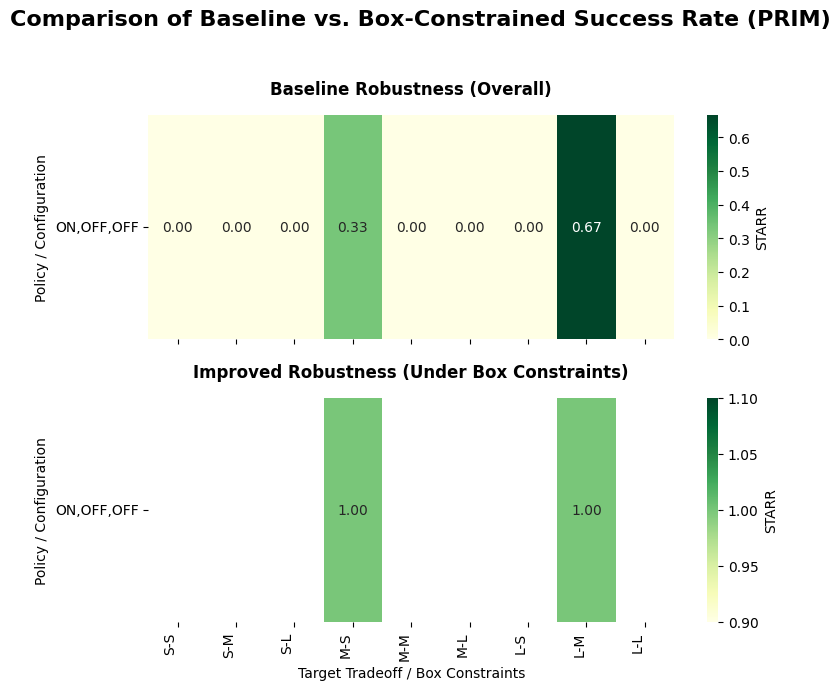

In [41]:
fig = session.show_policy_robustness_comparison_heatmap(
    baseline_matrix=base_robustness_matrix,
    improved_matrix=prim_robustness_improvement_matrix,
    boxes=prim_box_list, 
    metric=metric, 
    figsize=(8,7),
    title="Comparison of Baseline vs. Box-Constrained Success Rate (PRIM)"
)

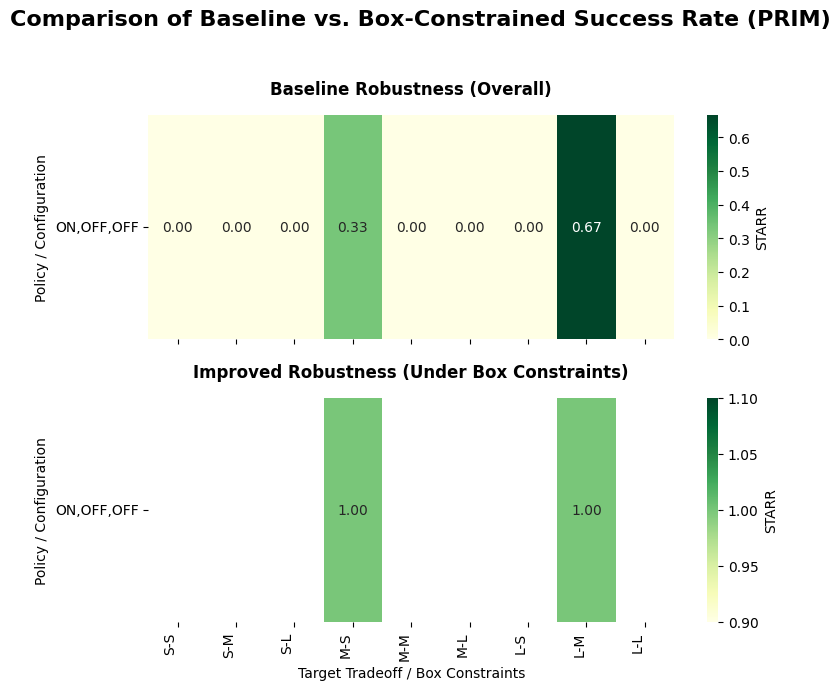

In [42]:
fig = session.show_policy_robustness_comparison_heatmap(
    baseline_matrix=base_robustness_matrix,
    improved_matrix=prim_robustness_improvement_matrix,
    boxes=prim_box_list, 
    metric=metric, 
    figsize=(8,7),
    title="Comparison of Baseline vs. Box-Constrained Success Rate (PRIM)"
)

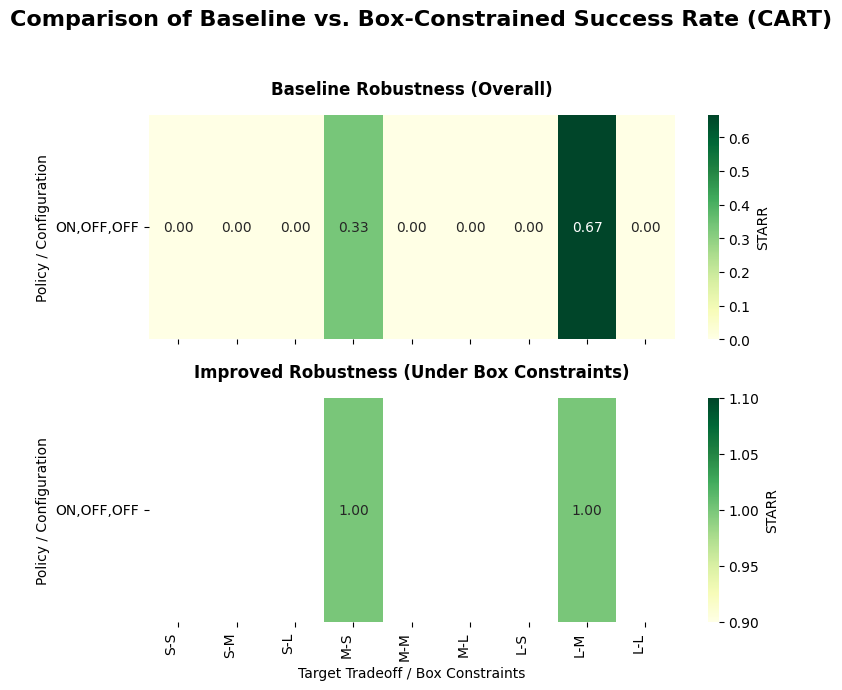

In [43]:
fig = session.show_policy_robustness_comparison_heatmap(
    baseline_matrix=base_robustness_matrix,
    improved_matrix=cart_robustness_improvement_matrix,
    boxes=cart_box_list, 
    metric=metric, 
    figsize=(8,7),
    title="Comparison of Baseline vs. Box-Constrained Success Rate (CART)"
)

## 12. Performance Metrics

In [44]:
# PRIM
scores = session.get_algorithm_performance_scores(prim_boxes, return_std=True, subset='test')
metrics_df = pd.DataFrame(scores.items(), columns=['metric', 'value'])
df = metrics_df.T
prim_df = pd.DataFrame(df.values[1:], columns=df.iloc[0])
metrics_df

2 tradeoffs to evaluate. 2 2


,metric,value
0,precision,1.000000
1,recall,1.000000
2,f1,1.000000
3,lift,0.500000
4,complexity,1.000000
5,success_rate,1.000000
6,precision_std,0.000000
7,recall_std,0.000000
8,f1_std,0.000000
9,lift_std,0.166667


In [45]:
# CART
scores = session.get_algorithm_performance_scores(cart_boxes, return_std=True, subset='test')
metrics_df = pd.DataFrame(scores.items(), columns=['metric', 'value'])
df = metrics_df.T
cart_df = pd.DataFrame(df.values[1:], columns=df.iloc[0])
metrics_df


2 tradeoffs to evaluate. 2 2


,metric,value
0,precision,1.000000
1,recall,1.000000
2,f1,1.000000
3,lift,0.500000
4,complexity,1.000000
5,success_rate,1.000000
6,precision_std,0.000000
7,recall_std,0.000000
8,f1_std,0.000000
9,lift_std,0.166667


In [46]:
all_metrics = pd.concat([prim_df, cart_df], axis=0)
all_metrics.index = ['prim', 'cart']
# all_metrics.to_csv('metrics-fl.csv', decimal=',')
all_metrics

metric,precision,recall,f1,lift,complexity,success_rate,precision_std,recall_std,f1_std,lift_std,complexity_std
prim,1.0,1.0,1.0,0.5,1.0,1.0,0.0,0.0,0.0,0.166667,0.0
cart,1.0,1.0,1.0,0.5,1.0,1.0,0.0,0.0,0.0,0.166667,0.0


## 13. Notebook Status (R11)

This notebook is now the canonical validation path for the Federated Learning
example, exercising the framework's real methodology end to end: model
summary (R4), spec linting (R1-R3), tradeoff definition, per-decision
contingency analysis, key-parameter selection with FL's policy-bound pattern
parameters included (R6), PRIM/CART scenario discovery, and box diagnostics
including a best-effort N/A-hatching check (R9/R10).

`federatedlearning/test_manual_simple.py`, `federatedlearning/test_nan_feature.ipynb`,
and the root `test_nan_manual.py` are retired as the primary validation path
(R11). They remain in place -- unmodified, not deleted -- but should no
longer be treated as the authoritative way to validate FL support; use this
notebook instead.